# Exploratory Data Analysis - Sales & Inventory Dataset
## Version: CSV Data Loading

This notebook explores a dataset containing sales, inventory, and product data for 123 products over a 3-year period (2023-2025). The data is designed for demand forecasting, inventory optimization, and supply chain analytics.

**Files:**
- `sales_train_2023_2024.csv` - Monthly sales & inventory (Jan 2023 - Dec 2024)
- `sales_test_2025.csv` - Monthly sales & inventory (Jan 2025 - Dec 2025)
- `products_parameters.csv` - Static product attributes
- `financial_plan.csv` - Annual sales plan/budget targets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

/kaggle/input/datasets/kacperjarosik1/warehouse-cost-optimization-pharmaceutical-company/financial_plan.csv
/kaggle/input/datasets/kacperjarosik1/warehouse-cost-optimization-pharmaceutical-company/products_parameters.csv
/kaggle/input/datasets/kacperjarosik1/warehouse-cost-optimization-pharmaceutical-company/sales_test_2025.csv
/kaggle/input/datasets/kacperjarosik1/warehouse-cost-optimization-pharmaceutical-company/.original_hackathon_data.xlsx
/kaggle/input/datasets/kacperjarosik1/warehouse-cost-optimization-pharmaceutical-company/sales_train_2023_2024.csv


## 1. Data Loading (CSV)

In [ ]:
# Load all CSV files
DATASET_DIR = '.'

sales_train = pd.read_csv(os.path.join(DATASET_DIR, 'sales_train_2023_2024.csv'))
sales_test = pd.read_csv(os.path.join(DATASET_DIR, 'sales_test_2025.csv'))
products = pd.read_csv(os.path.join(DATASET_DIR, 'products_parameters.csv'))
financial_plan = pd.read_csv(os.path.join(DATASET_DIR, 'financial_plan.csv'))

print(f"Sales Train shape: {sales_train.shape}")
print(f"Sales Test shape: {sales_test.shape}")
print(f"Products shape: {products.shape}")
print(f"Financial Plan shape: {financial_plan.shape}")

Sales Train shape: (500, 27)
Sales Test shape: (500, 15)
Products shape: (250, 7)
Financial Plan shape: (250, 9)


## 2. Data Overview

In [3]:
print("=" * 60)
print("SALES TRAIN (2023-2024)")
print("=" * 60)
sales_train.head(6)

SALES TRAIN (2023-2024)


,ProductID,Product_name,Type,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,P001,Product 001,Sales,56,47,43,40,50,72,66,62,43,52,58,43,53,35,44,55,44,61,81,59,46,53,63,47
1,P001,Product 001,Inventory_level,219,172,129,89,39,237,171,109,66,14,274,231,178,143,99,44,0,229,148,89,43,366,303,256
2,P002,Product 002,Sales,34,29,34,29,28,32,37,34,39,27,28,33,44,37,28,33,35,31,37,33,32,41,25,29
3,P002,Product 002,Inventory_level,200,171,137,108,80,48,11,240,201,174,146,113,69,32,4,265,230,199,162,129,97,56,31,2
4,P003,Product 003,Sales,67,62,68,55,57,59,61,82,78,64,68,51,65,68,78,70,71,70,70,53,63,82,76,72
5,P003,Product 003,Inventory_level,232,170,102,47,302,243,182,100,22,328,260,209,144,76,306,236,165,95,25,326,263,181,105,33


In [4]:
print("=" * 60)
print("SALES TEST (2025)")
print("=" * 60)
sales_test.head(6)

SALES TEST (2025)


,ProductID,Product_name,Type,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,P001,Product 001,Sales,54,59,51,46,45,52,77,67,62,55,43,39
1,P001,Product 001,Inventory_level,202,143,92,46,1,237,160,93,31,392,349,310
2,P002,Product 002,Sales,30,30,31,37,41,40,30,35,38,37,43,32
3,P002,Product 002,Inventory_level,230,200,169,132,91,51,21,284,246,209,166,134
4,P003,Product 003,Sales,68,74,58,51,64,73,69,78,71,68,82,80
5,P003,Product 003,Inventory_level,350,276,218,167,103,30,277,199,128,60,344,264


In [5]:
print("=" * 60)
print("PRODUCT PARAMETERS")
print("=" * 60)
products.head(10)

PRODUCT PARAMETERS


,ProductID,Product_name,Storage_cost_PLN_per_unit_month,Shelf_life_months,Lead_time_months,Safety_stock_months,Price_PLN_per_unit
0,P001,Product 001,0.34,20,3,0.7,20.62
1,P002,Product 002,0.20,22,2,1.2,10.03
2,P003,Product 003,0.95,15,1,1.1,36.01
3,P004,Product 004,0.67,12,3,1.4,28.22
4,P005,Product 005,1.47,12,2,1.8,84.54
5,P006,Product 006,0.89,14,3,0.9,35.65
6,P007,Product 007,0.71,14,3,0.6,15.30
7,P008,Product 008,0.46,18,1,1.3,8.61
8,P009,Product 009,1.02,12,1,1.5,45.15
9,P010,Product 010,0.93,24,2,1.4,22.46


In [6]:
print("=" * 60)
print("FINANCIAL PLAN")
print("=" * 60)
financial_plan.head(10)

FINANCIAL PLAN


,ProductID,Product_name,Plan_2023_units,Plan_2024_units,Plan_2025_units,Plan_2023_PLN,Plan_2024_PLN,Plan_2025_PLN,Price_PLN_per_unit
0,P001,Product 001,486,695,543,10021.32,14330.90,11196.66,20.62
1,P002,Product 002,347,376,360,3480.41,3771.28,3610.80,10.03
2,P003,Product 003,599,849,818,21569.99,30572.49,29456.18,36.01
3,P004,Product 004,1024,1920,1693,28897.28,54182.40,47776.46,28.22
4,P005,Product 005,333,406,321,28151.82,34323.24,27137.34,84.54
5,P006,Product 006,452,748,479,16113.80,26666.20,17076.35,35.65
6,P007,Product 007,928,965,992,14198.40,14764.50,15177.60,15.30
7,P008,Product 008,1644,2023,1105,14154.84,17418.03,9514.05,8.61
8,P009,Product 009,998,1182,872,45059.70,53367.30,39370.80,45.15
9,P010,Product 010,890,1084,1163,19989.40,24346.64,26120.98,22.46


In [7]:
# Data types and missing values
print("\n--- Sales Train Info ---")
print(sales_train.info())
print(f"\nMissing values: {sales_train.isnull().sum().sum()}")

print("\n--- Products Info ---")
print(products.info())
print(f"\nMissing values: {products.isnull().sum().sum()}")


--- Sales Train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ProductID     500 non-null    object
 1   Product_name  500 non-null    object
 2   Type          500 non-null    object
 3   2023-01       500 non-null    int64 
 4   2023-02       500 non-null    int64 
 5   2023-03       500 non-null    int64 
 6   2023-04       500 non-null    int64 
 7   2023-05       500 non-null    int64 
 8   2023-06       500 non-null    int64 
 9   2023-07       500 non-null    int64 
 10  2023-08       500 non-null    int64 
 11  2023-09       500 non-null    int64 
 12  2023-10       500 non-null    int64 
 13  2023-11       500 non-null    int64 
 14  2023-12       500 non-null    int64 
 15  2024-01       500 non-null    int64 
 16  2024-02       500 non-null    int64 
 17  2024-03       500 non-null    int64 
 18  2024-04       500 non-nu

## 3. Data Transformation - Long Format

In [8]:
# Separate Sales and Inventory rows
def transform_to_long(df, year_label):
    """Transform wide format sales/inventory data to long format."""
    id_cols = ['ProductID', 'Product_name', 'Type']
    value_cols = [c for c in df.columns if c not in id_cols]
    
    long_df = df.melt(id_vars=id_cols, value_vars=value_cols,
                      var_name='Month', value_name='Value')
    long_df['Month'] = pd.to_datetime(long_df['Month'])
    return long_df

# Transform train and test
train_long = transform_to_long(sales_train, '2023-2024')
test_long = transform_to_long(sales_test, '2025')

# Combine all data
all_data_long = pd.concat([train_long, test_long], ignore_index=True)

# Pivot to have Sales and Inventory as separate columns
all_data_pivot = all_data_long.pivot_table(
    index=['ProductID', 'Product_name', 'Month'],
    columns='Type',
    values='Value'
).reset_index()
all_data_pivot.columns.name = None

print(f"Combined long format shape: {all_data_pivot.shape}")
all_data_pivot.head(10)

Combined long format shape: (9000, 5)


,ProductID,Product_name,Month,Inventory_level,Sales
0,P001,Product 001,2023-01-01,219.0,56.0
1,P001,Product 001,2023-02-01,172.0,47.0
2,P001,Product 001,2023-03-01,129.0,43.0
3,P001,Product 001,2023-04-01,89.0,40.0
4,P001,Product 001,2023-05-01,39.0,50.0
5,P001,Product 001,2023-06-01,237.0,72.0
6,P001,Product 001,2023-07-01,171.0,66.0
7,P001,Product 001,2023-08-01,109.0,62.0
8,P001,Product 001,2023-09-01,66.0,43.0
9,P001,Product 001,2023-10-01,14.0,52.0


## 4. Sales Analysis

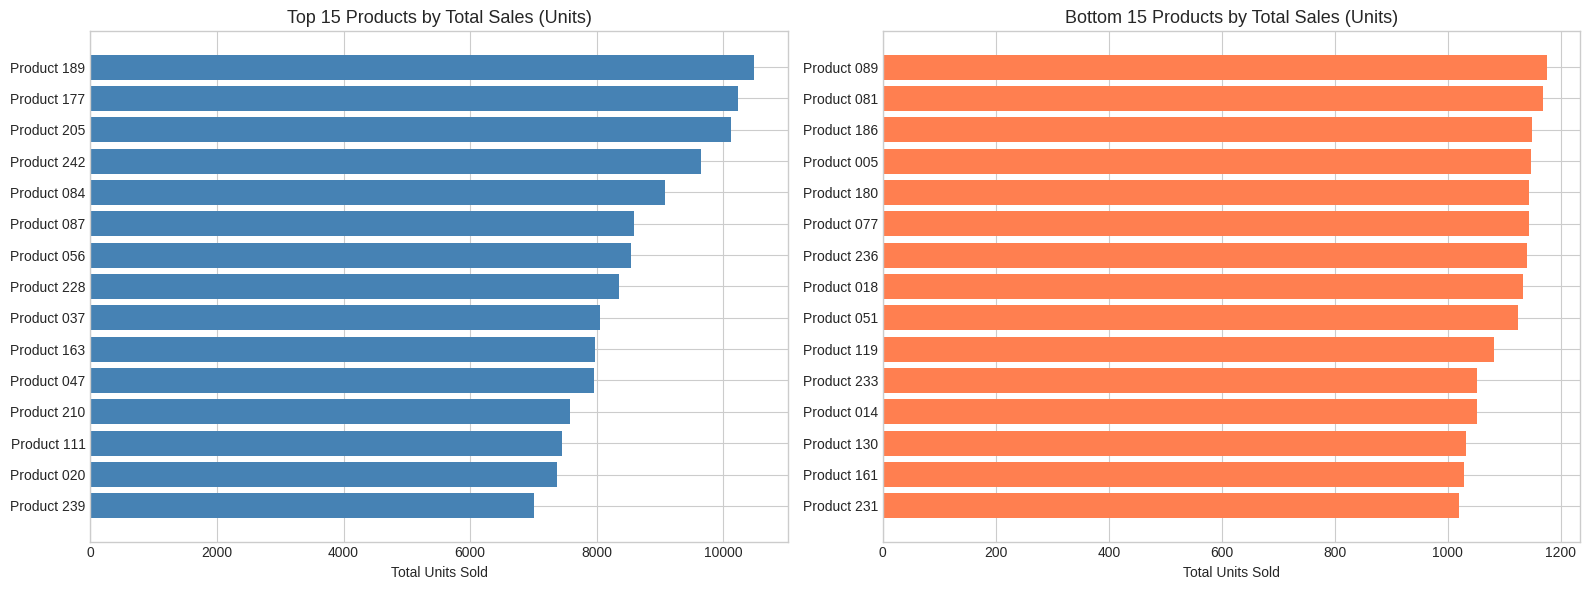

In [9]:
# Total sales per product (all years)
total_sales = all_data_pivot.groupby(['ProductID', 'Product_name'])['Sales'].sum().reset_index()
total_sales = total_sales.sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 products by total sales
axes[0].barh(total_sales.head(15)['Product_name'], total_sales.head(15)['Sales'], color='steelblue')
axes[0].set_title('Top 15 Products by Total Sales (Units)', fontsize=13)
axes[0].set_xlabel('Total Units Sold')
axes[0].invert_yaxis()

# Bottom 15 products by total sales
axes[1].barh(total_sales.tail(15)['Product_name'], total_sales.tail(15)['Sales'], color='coral')
axes[1].set_title('Bottom 15 Products by Total Sales (Units)', fontsize=13)
axes[1].set_xlabel('Total Units Sold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

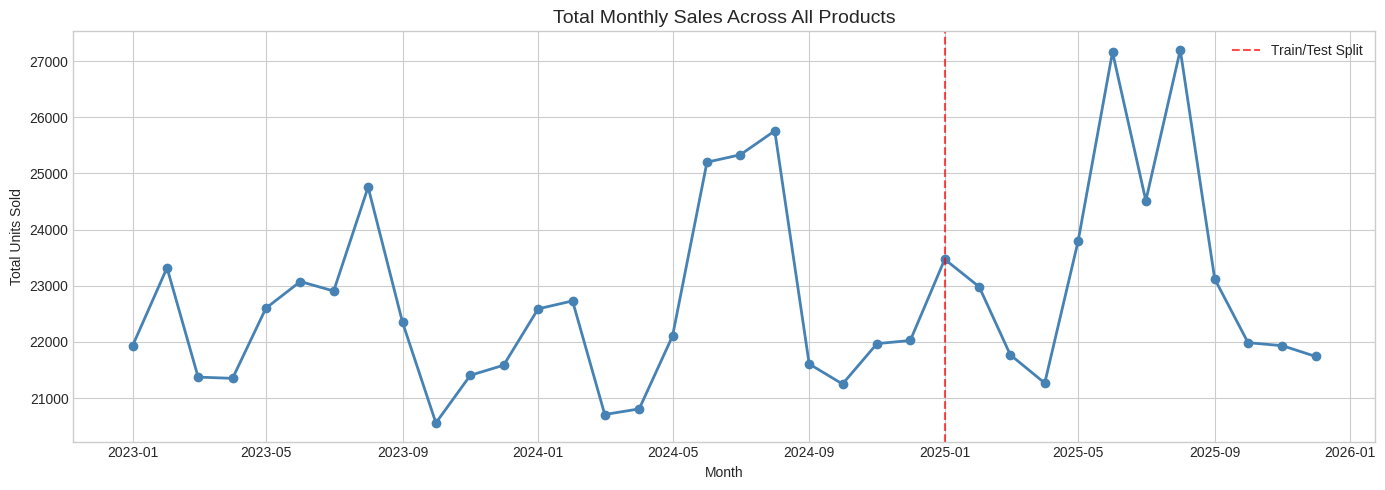

In [10]:
# Monthly total sales across all products
monthly_total = all_data_pivot.groupby('Month')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_total['Month'], monthly_total['Sales'], marker='o', linewidth=2, color='steelblue')
ax.axvline(pd.Timestamp('2025-01-01'), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
ax.set_title('Total Monthly Sales Across All Products', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Units Sold')
ax.legend()
plt.tight_layout()
plt.show()

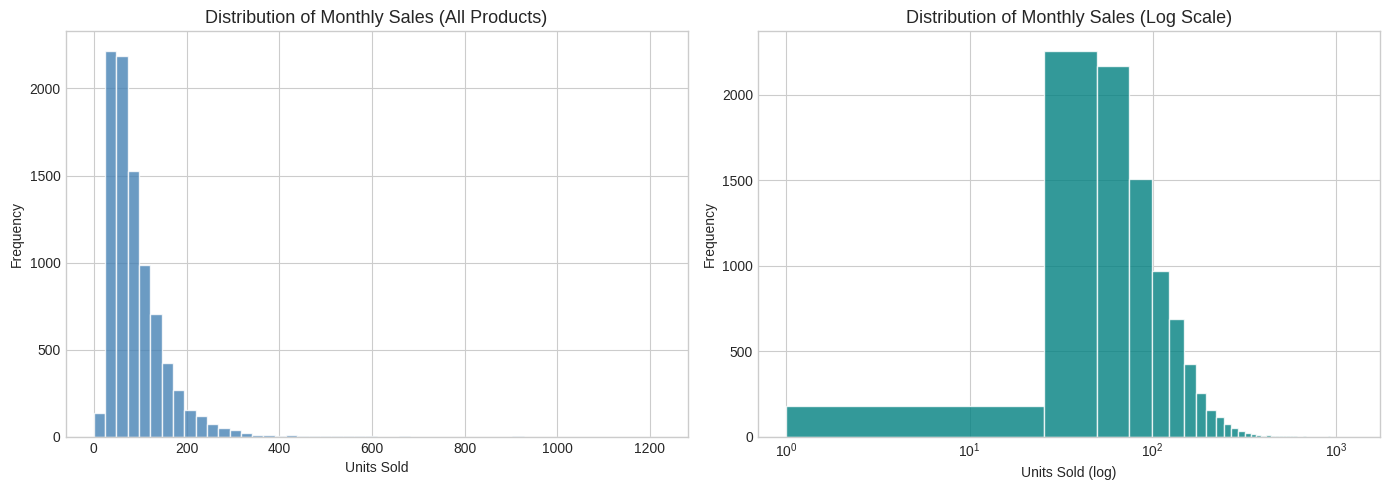


Sales Statistics:
count    9000.000000
mean       91.131000
std        69.735742
min         0.000000
25%        48.000000
50%        73.000000
75%       113.000000
max      1220.000000
Name: Sales, dtype: float64


In [11]:
# Sales distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_data_pivot['Sales'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Monthly Sales (All Products)', fontsize=13)
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')

# Log scale
axes[1].hist(all_data_pivot['Sales'].clip(lower=1), bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_title('Distribution of Monthly Sales (Log Scale)', fontsize=13)
axes[1].set_xlabel('Units Sold (log)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"\nSales Statistics:")
print(all_data_pivot['Sales'].describe())

## 5. Inventory Analysis

In [12]:
# Stockout analysis (Inventory_level = 0)
stockouts = all_data_pivot[all_data_pivot['Inventory_level'] == 0]
stockout_counts = stockouts.groupby('ProductID').size().reset_index(name='Stockout_Months')
stockout_counts = stockout_counts.sort_values('Stockout_Months', ascending=False)

print(f"Total stockout events: {len(stockouts)}")
print(f"Products with at least one stockout: {len(stockout_counts)}")
print(f"\nTop 10 products by stockout frequency:")
print(stockout_counts.head(10).to_string(index=False))

Total stockout events: 182
Products with at least one stockout: 109

Top 10 products by stockout frequency:
ProductID  Stockout_Months
     P174                6
     P210                5
     P214                5
     P171                4
     P037                4
     P084                3
     P150                3
     P117                3
     P181                3
     P094                3


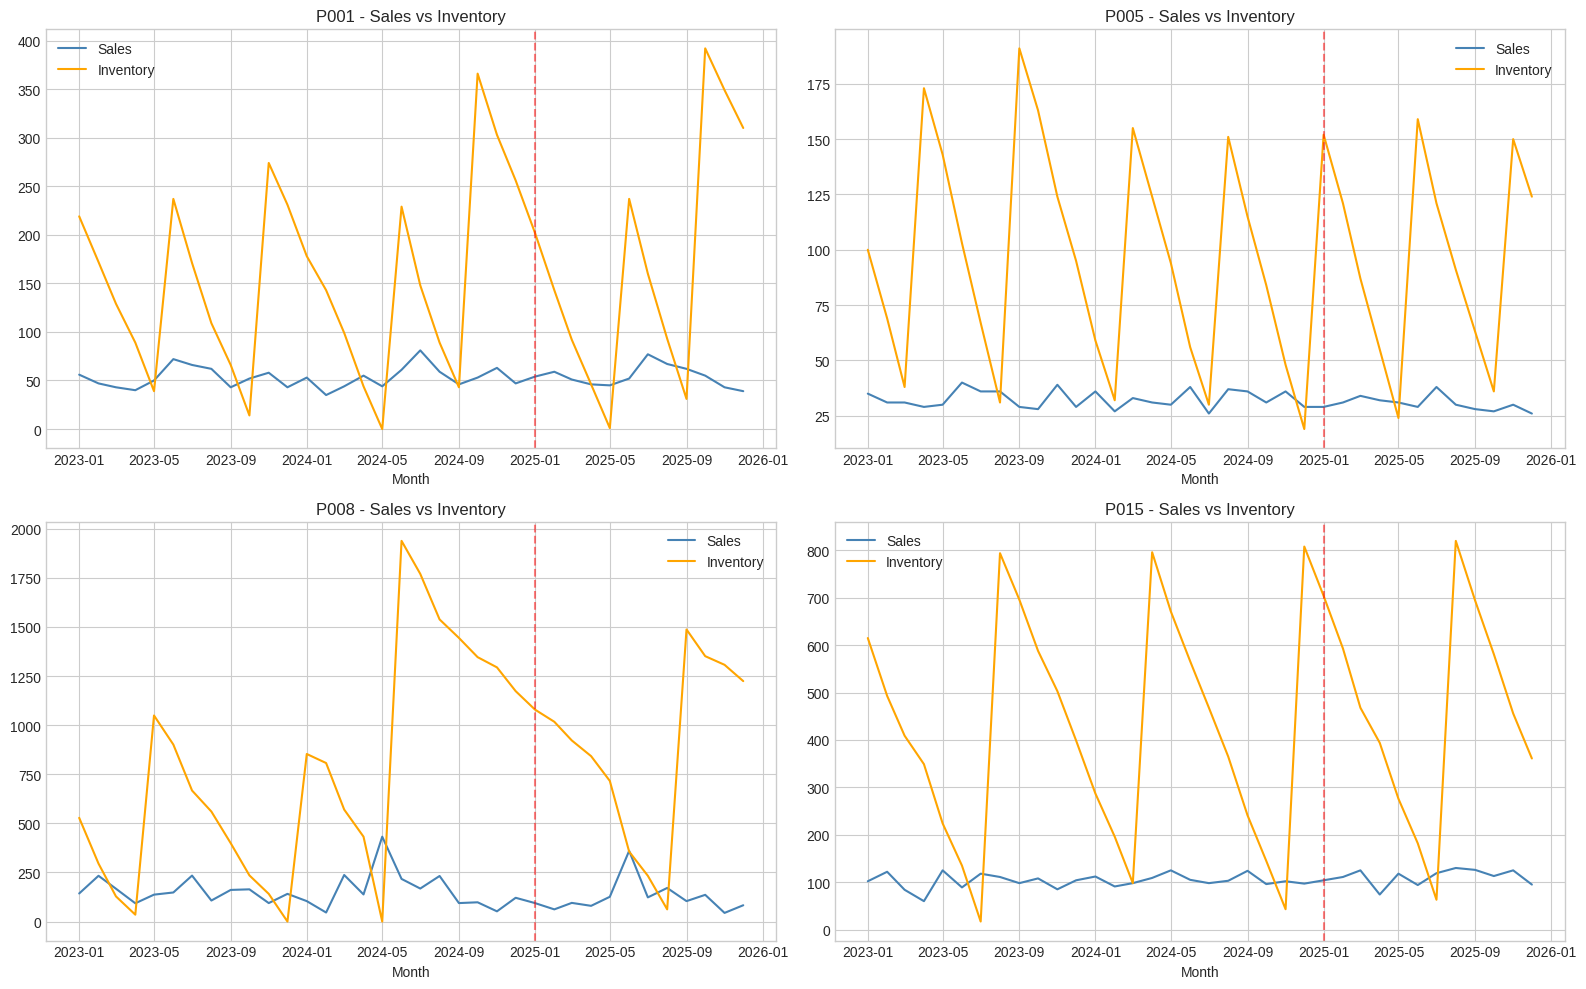

In [13]:
# Inventory level trends for sample products
sample_products = ['P001', 'P005', 'P008', 'P015']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, pid in enumerate(sample_products):
    product_data = all_data_pivot[all_data_pivot['ProductID'] == pid]
    ax = axes[i]
    ax.plot(product_data['Month'], product_data['Sales'], label='Sales', color='steelblue', linewidth=1.5)
    ax.plot(product_data['Month'], product_data['Inventory_level'], label='Inventory', color='orange', linewidth=1.5)
    ax.axvline(pd.Timestamp('2025-01-01'), color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{pid} - Sales vs Inventory', fontsize=12)
    ax.legend()
    ax.set_xlabel('Month')

plt.tight_layout()
plt.show()

## 6. Product Parameters Analysis

In [14]:
# Product parameters summary statistics
print("Product Parameters Summary:")
print(products.describe().round(2))

Product Parameters Summary:
       Storage_cost_PLN_per_unit_month  Shelf_life_months  Lead_time_months  \
count                           250.00             250.00            250.00   
mean                              0.84              16.51              2.04   
std                               0.40               4.69              0.83   
min                               0.20               9.00              1.00   
25%                               0.57              12.00              1.00   
50%                               0.80              16.00              2.00   
75%                               1.07              21.00              3.00   
max                               2.61              24.00              3.00   

       Safety_stock_months  Price_PLN_per_unit  
count               250.00              250.00  
mean                  1.30               39.29  
std                   0.43               31.83  
min                   0.50                8.00  
25%            

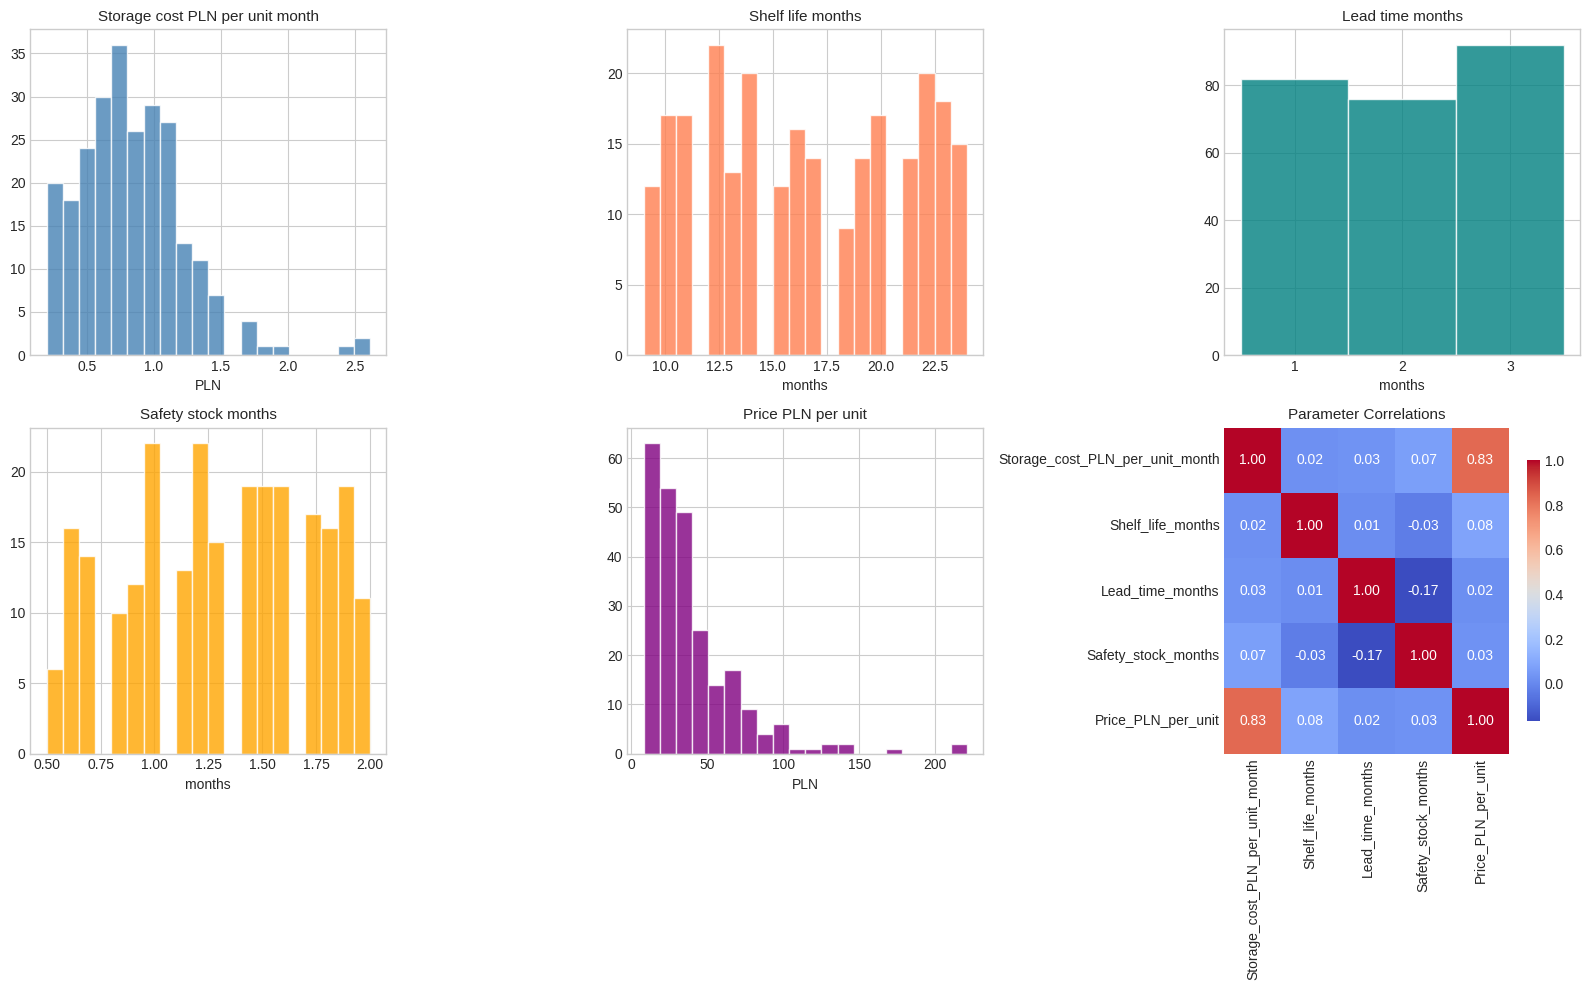

In [15]:
# Distributions of product parameters
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
params = ['Storage_cost_PLN_per_unit_month', 'Shelf_life_months', 'Lead_time_months',
           'Safety_stock_months', 'Price_PLN_per_unit']
colors = ['steelblue', 'coral', 'teal', 'orange', 'purple']

for i, (param, color) in enumerate(zip(params, colors)):
    ax = axes.flatten()[i]
    if param == 'Lead_time_months':
        ax.hist(products[param], bins=range(int(products[param].min()), int(products[param].max()) + 2), color=color, edgecolor='white', alpha=0.8, align='left')
        ax.xaxis.set_major_locator(plt.MultipleLocator(1))
    else:
        ax.hist(products[param], bins=20, color=color, edgecolor='white', alpha=0.8)
    ax.set_title(param.replace('_', ' '), fontsize=11)
    ax.set_xlabel(param.split('_')[-1] if 'PLN' not in param else 'PLN')

# Correlation heatmap in last subplot
ax = axes.flatten()[5]
corr = products.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Parameter Correlations', fontsize=11)

plt.tight_layout()
plt.show()

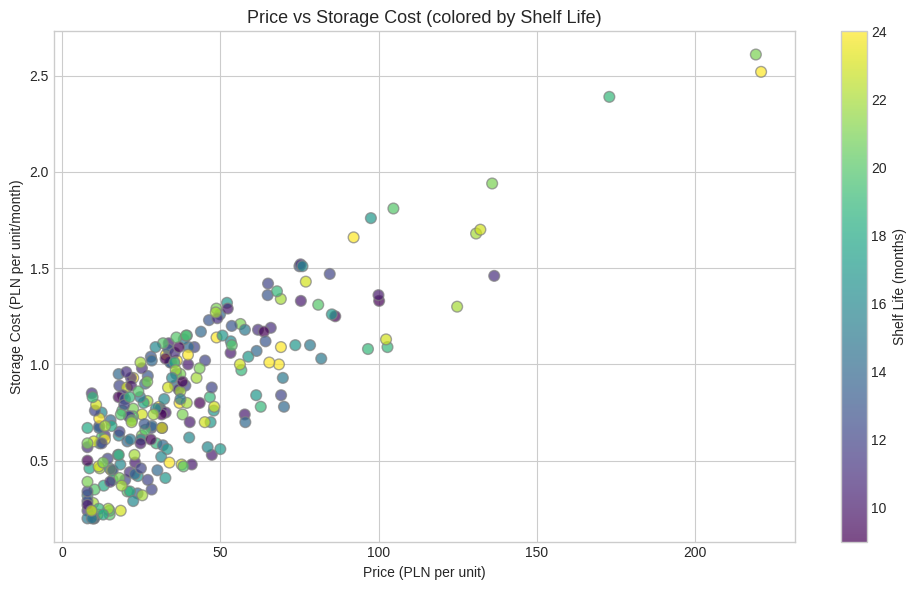

In [16]:
# Price vs Storage cost
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(products['Price_PLN_per_unit'], 
                     products['Storage_cost_PLN_per_unit_month'],
                     c=products['Shelf_life_months'], 
                     cmap='viridis', s=60, alpha=0.7, edgecolors='gray')
plt.colorbar(scatter, label='Shelf Life (months)')
ax.set_xlabel('Price (PLN per unit)')
ax.set_ylabel('Storage Cost (PLN per unit/month)')
ax.set_title('Price vs Storage Cost (colored by Shelf Life)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Financial Plan Analysis

In [17]:
# Plan vs Actual comparison (2023 & 2024)
# Calculate actual annual sales from training data
sales_only = all_data_pivot[['ProductID', 'Month', 'Sales']].copy()
sales_only['Year'] = sales_only['Month'].dt.year

actual_annual = sales_only.groupby(['ProductID', 'Year'])['Sales'].sum().reset_index()
actual_annual = actual_annual.rename(columns={'Sales': 'Actual_Units'})

# Merge with plan
plan_melted = financial_plan.melt(
    id_vars=['ProductID', 'Product_name', 'Price_PLN_per_unit'],
    value_vars=['Plan_2023_units', 'Plan_2024_units', 'Plan_2025_units'],
    var_name='Plan_Year', value_name='Plan_Units'
)
plan_melted['Year'] = plan_melted['Plan_Year'].str.extract(r'(\d{4})').astype(int)

comparison = actual_annual.merge(plan_melted[['ProductID', 'Year', 'Plan_Units']], on=['ProductID', 'Year'])
comparison['Plan_Achievement_pct'] = (comparison['Actual_Units'] / comparison['Plan_Units'] * 100).round(1)

print("Plan Achievement Summary (%) by Year:")
print(comparison.groupby('Year')['Plan_Achievement_pct'].describe().round(1))

Plan Achievement Summary (%) by Year:
      count   mean   std   min    25%    50%    75%    max
Year                                                      
2023  250.0  108.4  14.6  81.9   98.0  106.0  118.4  146.5
2024  250.0  107.4  13.4  81.9   97.3  106.0  115.3  146.5
2025  250.0  109.6  13.6  81.9  100.1  108.4  118.2  146.6


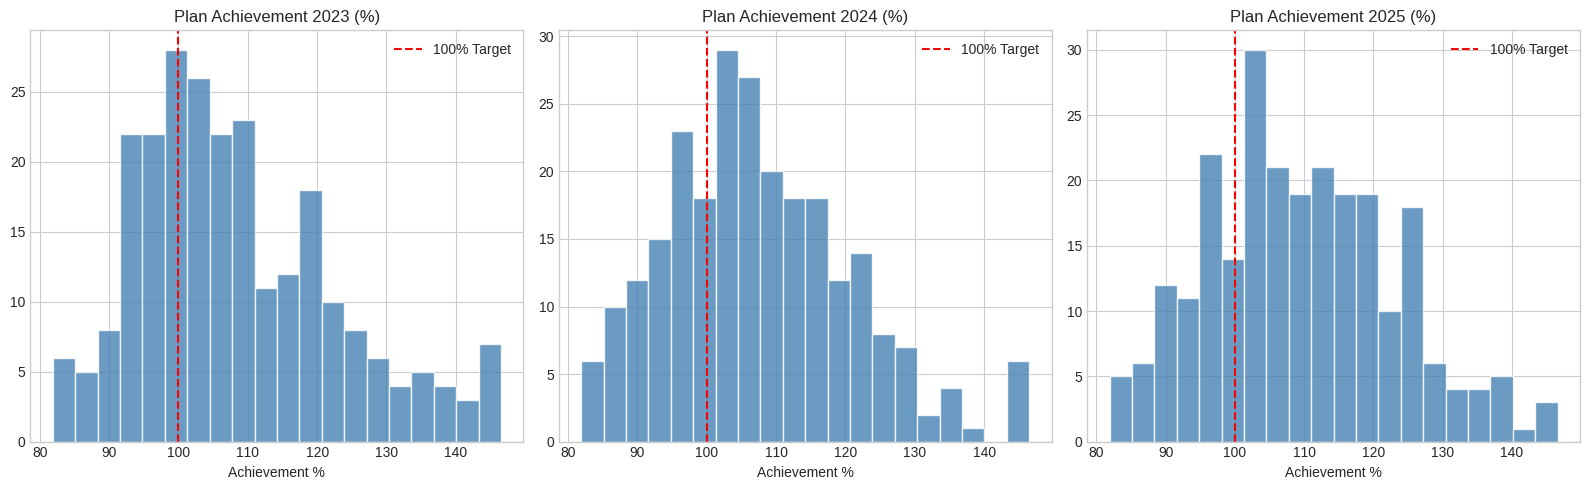

In [18]:
# Plan achievement distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, year in enumerate([2023, 2024, 2025]):
    year_data = comparison[comparison['Year'] == year]
    if len(year_data) > 0:
        axes[i].hist(year_data['Plan_Achievement_pct'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].axvline(100, color='red', linestyle='--', label='100% Target')
        axes[i].set_title(f'Plan Achievement {year} (%)', fontsize=12)
        axes[i].set_xlabel('Achievement %')
        axes[i].legend()
    else:
        axes[i].set_title(f'Plan Achievement {year} - No Data', fontsize=12)

plt.tight_layout()
plt.show()

## 8. Seasonality Analysis

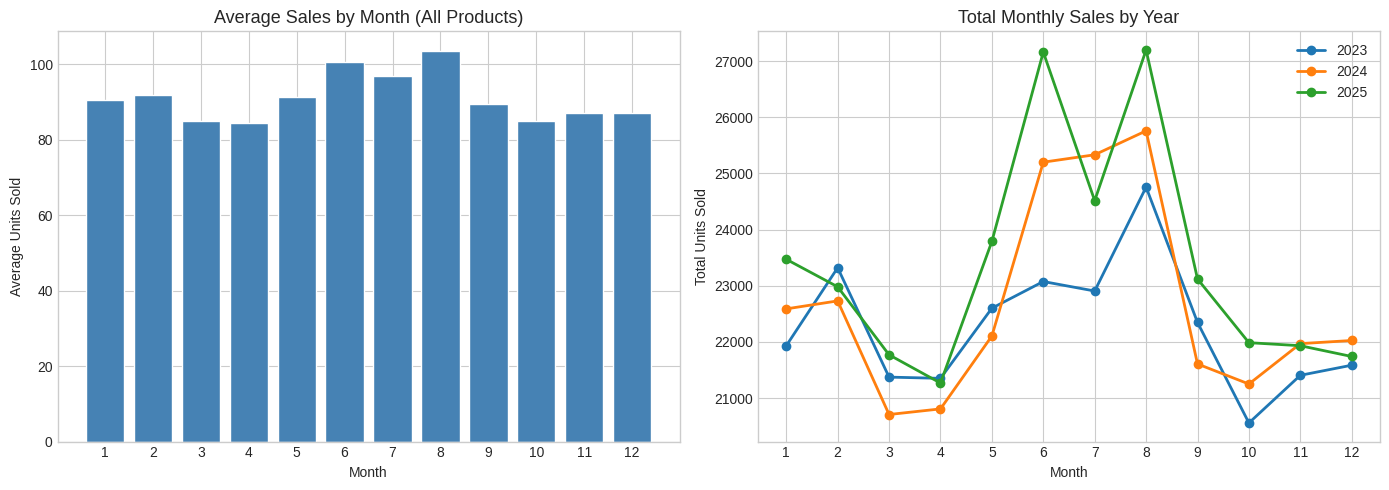

In [19]:
# Monthly seasonality patterns
all_data_pivot['Month_num'] = all_data_pivot['Month'].dt.month
all_data_pivot['Year'] = all_data_pivot['Month'].dt.year

monthly_avg = all_data_pivot.groupby('Month_num')['Sales'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall seasonality
axes[0].bar(monthly_avg['Month_num'], monthly_avg['Sales'], color='steelblue', edgecolor='white')
axes[0].set_title('Average Sales by Month (All Products)', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Units Sold')
axes[0].set_xticks(range(1, 13))

# Year-over-year comparison
yearly_monthly = all_data_pivot.groupby(['Year', 'Month_num'])['Sales'].sum().reset_index()
for year in [2023, 2024, 2025]:
    year_data = yearly_monthly[yearly_monthly['Year'] == year]
    axes[1].plot(year_data['Month_num'], year_data['Sales'], marker='o', label=str(year), linewidth=2)

axes[1].set_title('Total Monthly Sales by Year', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Units Sold')
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Key Metrics & Summary

In [20]:
# Merge product parameters with sales summary
product_summary = total_sales.merge(products, on=['ProductID', 'Product_name'])
product_summary['Total_Revenue_PLN'] = product_summary['Sales'] * product_summary['Price_PLN_per_unit']
product_summary['Total_Storage_Cost_PLN'] = (
    product_summary['Storage_cost_PLN_per_unit_month'] * 
    all_data_pivot.groupby('ProductID')['Inventory_level'].mean().values * 36  # 36 months
)

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total products: {len(products)}")
print(f"Time period: Jan 2023 - Dec 2025 (36 months)")
print(f"Training period: 24 months | Test period: 12 months")
print(f"\nTotal units sold (all time): {all_data_pivot['Sales'].sum():,.0f}")
print(f"Average monthly sales per product: {all_data_pivot['Sales'].mean():.1f} units")
print(f"\nStockout events (inventory=0): {(all_data_pivot['Inventory_level'] == 0).sum()}")
print(f"Products experiencing stockouts: {len(stockout_counts)}")
print(f"\nPrice range: {products['Price_PLN_per_unit'].min():.2f} - {products['Price_PLN_per_unit'].max():.2f} PLN")
print(f"Lead time range: {products['Lead_time_months'].min()} - {products['Lead_time_months'].max()} months")
print(f"Shelf life range: {products['Shelf_life_months'].min()} - {products['Shelf_life_months'].max()} months")

DATASET SUMMARY
Total products: 250
Time period: Jan 2023 - Dec 2025 (36 months)
Training period: 24 months | Test period: 12 months

Total units sold (all time): 820,179
Average monthly sales per product: 91.1 units

Stockout events (inventory=0): 182
Products experiencing stockouts: 109

Price range: 8.00 - 220.81 PLN
Lead time range: 1 - 3 months
Shelf life range: 9 - 24 months


In [21]:
# Top products by estimated revenue
top_revenue = product_summary.nlargest(15, 'Total_Revenue_PLN')[['ProductID', 'Product_name', 'Sales', 'Price_PLN_per_unit', 'Total_Revenue_PLN']]
top_revenue['Total_Revenue_PLN'] = top_revenue['Total_Revenue_PLN'].round(2)

print("\nTop 15 Products by Estimated Revenue (PLN):")
print(top_revenue.to_string(index=False))


Top 15 Products by Estimated Revenue (PLN):
ProductID Product_name   Sales  Price_PLN_per_unit  Total_Revenue_PLN
     P242  Product 242  9648.0               67.87          654809.76
     P181  Product 181  4602.0              135.85          625181.70
     P028  Product 028  2623.0              220.81          579184.63
     P220  Product 220  3948.0              132.12          521609.76
     P108  Product 108  2291.0              219.16          502095.56
     P134  Product 134  6978.0               69.17          482668.26
     P173  Product 173  5832.0               78.32          456762.24
     P157  Product 157  4511.0               92.08          415372.88
     P197  Product 197  6365.0               64.93          413279.45
     P043  Product 043  4789.0               86.28          413194.92
     P085  Product 085  4848.0               81.85          396808.80
     P185  Product 185  3033.0              130.77          396625.41
     P192  Product 192  6416.0               